In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from backtesting import Strategy, Backtest

def fetch_h4(symbol: str = "^DJI", period: str = "730d") -> pd.DataFrame:
    raw = yf.download(symbol, period=period, interval="60m", auto_adjust=True, progress=False)
    if raw.empty:
        raise RuntimeError(f"No data returned for {symbol}.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.rename(columns=str.lower)
    raw = raw[["open", "high", "low", "close", "volume"]]
    h4 = raw.resample("4h").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
    ).dropna(how="any")
    h4.index.name = "time"
    return h4

df = fetch_h4("GC=F")
print(df.shape)

c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

(1707, 5)


In [2]:
def sma(series, length):
    return series.rolling(window=length, min_periods=length).mean()

def ema(series, length):
    return series.ewm(span=length, adjust=False, min_periods=length).mean()

def macd(close, fast=12, slow=26, signal=9):
    macd_line = ema(close, fast) - ema(close, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def true_range(high, low, close):
    prev_close = close.shift(1)
    return pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)

def atr(high, low, close, length=14):
    tr = true_range(high, low, close)
    return tr.ewm(alpha=1/length, adjust=False, min_periods=length).mean()

def adx(high, low, close, length=14):
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=high.index)
    atr_wilder = true_range(high, low, close).ewm(alpha=1/length, adjust=False, min_periods=length).mean()
    plus_di = 100 * (plus_dm.ewm(alpha=1/length, adjust=False, min_periods=length).mean() / atr_wilder)
    minus_di = 100 * (minus_dm.ewm(alpha=1/length, adjust=False, min_periods=length).mean() / atr_wilder)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx_line = dx.ewm(alpha=1/length, adjust=False, min_periods=length).mean()
    return plus_di, minus_di, adx_line

df["ma_360"] = sma(df["close"], 360)
df["ma_200"] = sma(df["close"], 200)
df["ma_89"] = sma(df["close"], 89)
df["ema_21"] = ema(df["close"], 21)
df["ema_8"] = ema(df["close"], 8)
df["macd"], df["macd_signal"], df["macd_hist"] = macd(df["close"])
df["atr_14"] = atr(df["high"], df["low"], df["close"])
df["plus_di"], df["minus_di"], df["adx_14"] = adx(df["high"], df["low"], df["close"])

bt_df = df.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"})
bt_df.tail()

Price,Open,High,Low,Close,Volume,ma_360,ma_200,ma_89,ema_21,ema_8,macd,macd_signal,macd_hist,atr_14,plus_di,minus_di,adx_14
time,,,,,,,,,,,,,,,,,
2026-07-15 12:00:00-04:00,52471.031250,52695.460938,52436.359375,52658.019531,186584901,49244.396463,49449.851816,51292.188904,52454.739931,52530.763648,131.351741,179.471588,-48.119847,368.282603,18.547441,19.166102,16.857284
2026-07-16 08:00:00-04:00,52924.859375,52924.859375,52578.781250,52612.210938,101227504,49257.667969,49465.477617,51324.822639,52469.055477,52548.863046,128.699064,169.317083,-40.618019,366.696569,21.765552,17.874071,16.354417
2026-07-16 12:00:00-04:00,52611.480469,52728.878906,52367.421875,52553.078125,220100546,49271.147049,49480.712500,51358.679117,52476.693899,52549.799730,120.436953,159.541057,-39.104104,366.322316,20.231518,20.735569,15.274129
2026-07-17 08:00:00-04:00,52426.460938,52610.968750,51986.738281,52410.941406,104449161,49284.100141,49495.243652,51388.348358,52470.716400,52518.942325,101.252746,147.883395,-46.630649,384.744327,17.886894,25.400000,15.422873
2026-07-17 12:00:00-04:00,52410.730469,52419.000000,52120.718750,52158.960938,185019456,49295.995757,49508.549512,51416.836245,52442.374994,52438.946461,64.967501,131.300216,-66.332715,378.568393,16.880221,23.970489,15.560991


In [4]:
def swing_high(high, n):
    return high.rolling(n).max().shift(1)

def swing_low(low, n):
    return low.rolling(n).min().shift(1)

class ConfluenceStrategy(Strategy):
    adx_threshold = 22
    swing_lookback = 20
    atr_sl_mult = 1.5
    atr_tp_mult = 2.5

    def init(self):
        d = self.data.df
        self.ma_360 = self.I(lambda: d["ma_360"], name="MA360")
        self.ma_200 = self.I(lambda: d["ma_200"], name="MA200")
        self.ema_21 = self.I(lambda: d["ema_21"], name="EMA21")
        self.ema_8 = self.I(lambda: d["ema_8"], name="EMA8")
        self.macd_line = self.I(lambda: d["macd"], name="MACD")
        self.macd_signal = self.I(lambda: d["macd_signal"], name="MACDsig")
        self.macd_hist = self.I(lambda: d["macd_hist"], name="MACDhist")
        self.adx_14 = self.I(lambda: d["adx_14"], name="ADX14")
        self.atr_14 = self.I(lambda: d["atr_14"], name="ATR14")
        self.swing_hi = self.I(lambda: swing_high(d["High"], self.swing_lookback), name="SwingHi")
        self.swing_lo = self.I(lambda: swing_low(d["Low"], self.swing_lookback), name="SwingLo")

    def next(self):
        price = self.data.Close[-1]
        atr = self.atr_14[-1]
        if np.isnan(atr) or np.isnan(self.ma_360[-1]) or np.isnan(self.adx_14[-1]) or np.isnan(self.swing_hi[-1]):
            return
        trending = self.adx_14[-1] > self.adx_threshold
        ema_bullish = self.ema_8[-1] > self.ema_21[-1]
        ema_bearish = self.ema_8[-1] < self.ema_21[-1]
        macd_bull = self.macd_hist[-1] > 0
        macd_bear = self.macd_hist[-1] < 0
        bos_up = price > self.swing_hi[-1]
        bos_down = price < self.swing_lo[-1]
        macro_uptrend = price > self.ma_360[-1] and price > self.ma_200[-1]
        macro_downtrend = price < self.ma_360[-1] and price < self.ma_200[-1]
        long_signal = trending and macro_uptrend and ema_bullish and macd_bull and bos_up
        short_signal = trending and macro_downtrend and ema_bearish and macd_bear and bos_down
        if not self.position:
            if long_signal:
                sl = price - self.atr_sl_mult * atr
                tp = price + self.atr_tp_mult * atr
                if sl < price:
                    self.buy(sl=sl, tp=tp, size=0.1)
            elif short_signal:
                sl = price + self.atr_sl_mult * atr
                tp = price - self.atr_tp_mult * atr
                if sl > price:
                    self.sell(sl=sl, tp=tp, size=0.1)
        else:
            if self.position.is_long and price < self.ema_21[-1] and not macro_uptrend:
                self.position.close()
            elif self.position.is_short and price > self.ema_21[-1] and not macro_downtrend:
                self.position.close()

In [5]:
def run_fold(train_start, train_end, test_end):
    train_slice = bt_df.loc[train_start:train_end]
    test_slice = bt_df.loc[train_end:test_end]

    bt_train = Backtest(train_slice, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
    opt_stats = bt_train.optimize(
        adx_threshold=range(15, 31, 5),
        swing_lookback=range(10, 41, 10),
        atr_sl_mult=[1.0, 1.5, 2.0, 2.5],
        atr_tp_mult=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
        maximize="SQN",
        constraint=lambda p: p.atr_tp_mult > p.atr_sl_mult,
    )
    params = {k: getattr(opt_stats._strategy, k)
              for k in ["adx_threshold", "swing_lookback", "atr_sl_mult", "atr_tp_mult"]}

    bt_test = Backtest(test_slice, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
    test_stats = bt_test.run(**params)
    return params, test_stats

data_start = bt_df.index[0]
data_end = bt_df.index[-1]

train_end = data_start + pd.DateOffset(months=12)
fold_results = []

while train_end + pd.DateOffset(months=3) <= data_end:
    test_end = train_end + pd.DateOffset(months=3)
    print(f"Fold: train [{data_start.date()} -> {train_end.date()}]  test [{train_end.date()} -> {test_end.date()}]")

    params, test_stats = run_fold(data_start, train_end, test_end)
    fold_results.append({
        "train_end": train_end, "test_end": test_end, "params": params,
        "return_pct": test_stats["Return [%]"], "win_rate": test_stats["Win Rate [%]"],
        "num_trades": test_stats["# Trades"], "profit_factor": test_stats["Profit Factor"],
        "sharpe": test_stats["Sharpe Ratio"],
    })
    print(f"  params={params}  Return={test_stats['Return [%]']:.2f}%  WinRate={test_stats['Win Rate [%]']:.1f}%  Trades={test_stats['# Trades']}")

    train_end = test_end

Fold: train [2023-08-18 -> 2024-08-18]  test [2024-08-18 -> 2024-11-18]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of 

  params={'adx_threshold': np.int64(20), 'swing_lookback': np.int64(40), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.0)}  Return=9.50%  WinRate=75.0%  Trades=4
Fold: train [2023-08-18 -> 2024-11-18]  test [2024-11-18 -> 2025-02-18]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of 

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.0)}  Return=1.65%  WinRate=40.0%  Trades=5
Fold: train [2023-08-18 -> 2025-02-18]  test [2025-02-18 -> 2025-05-18]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of 

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=9.70%  WinRate=42.9%  Trades=7
Fold: train [2023-08-18 -> 2025-05-18]  test [2025-05-18 -> 2025-08-18]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
C:\Users\milat\AppData\Local\Temp\ipykernel_20604\1022355414.py:18: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  test_stats = bt_test.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiproc

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=8.12%  WinRate=50.0%  Trades=4
Fold: train [2023-08-18 -> 2025-08-18]  test [2025-08-18 -> 2025-11-18]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=-7.46%  WinRate=0.0%  Trades=4
Fold: train [2023-08-18 -> 2025-11-18]  test [2025-11-18 -> 2026-02-18]


C:\Users\milat\AppData\Local\Temp\ipykernel_20604\1022355414.py:17: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_test = Backtest(test_slice, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_20604\1022355414.py:5: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_train = Backtest(train_slice, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-pr

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=-5.44%  WinRate=0.0%  Trades=4
Fold: train [2023-08-18 -> 2026-02-18]  test [2026-02-18 -> 2026-05-18]
  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(1.0), 'atr_tp_mult': np.float64(2.5)}  Return=-7.60%  WinRate=16.7%  Trades=6


C:\Users\milat\AppData\Local\Temp\ipykernel_20604\1022355414.py:17: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_test = Backtest(test_slice, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)


Total trades across all folds: 34
Overall (approx) win rate: 32.4%
Starting equity: $50,000  ->  Final equity after all folds: $53,373.45
Total compounded return: 6.75%

                   test_end  return_pct   win_rate  num_trades  \
0 2024-11-18 08:00:00-05:00    9.504155  75.000000           4   
1 2025-02-18 08:00:00-05:00    1.647311  40.000000           5   
2 2025-05-18 08:00:00-04:00    9.704741  42.857143           7   
3 2025-08-18 08:00:00-04:00    8.117682  50.000000           4   
4 2025-11-18 08:00:00-05:00   -7.462570   0.000000           4   
5 2026-02-18 08:00:00-05:00   -5.436766   0.000000           4   
6 2026-05-18 08:00:00-04:00   -7.601081  16.666667           6   

   equity_after_fold  
0       54752.077282  
1       55654.014140  
2       61055.092141  
3       66011.350549  
4       61085.206990  
5       57764.147179  
6       53373.447577  


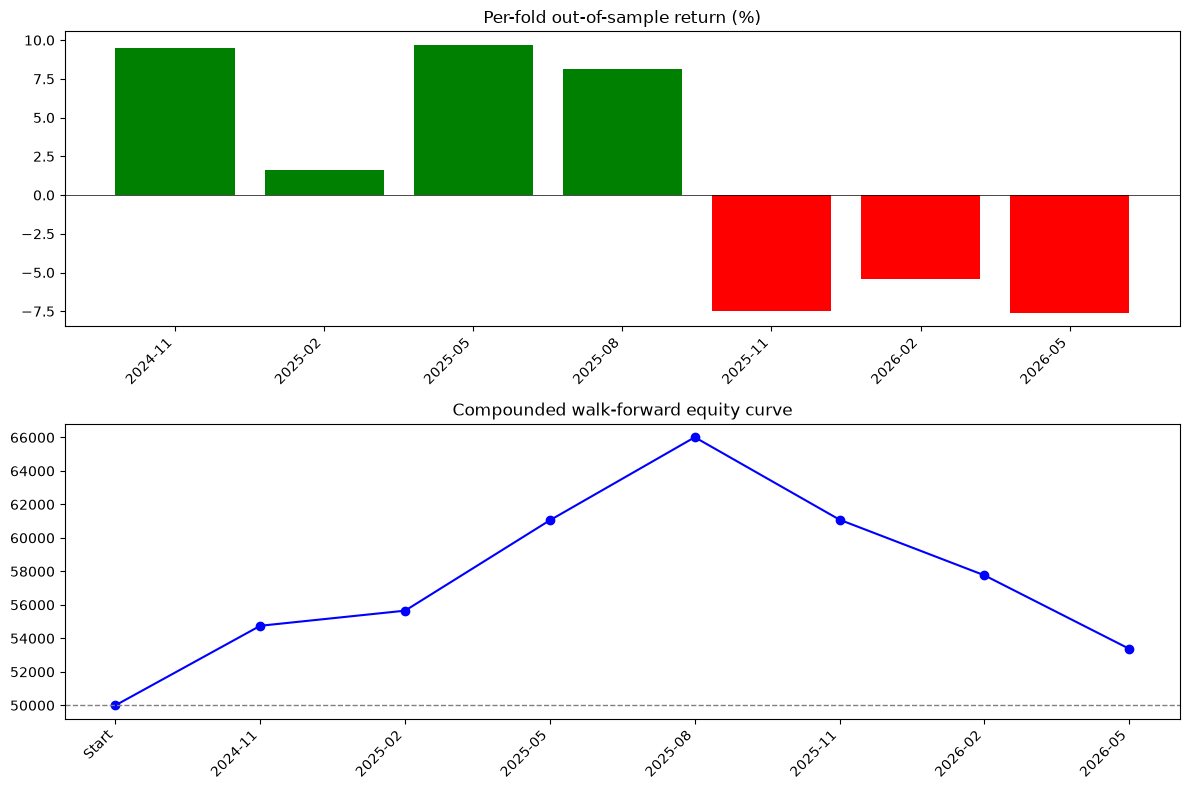

In [6]:
results_df = pd.DataFrame(fold_results)
results_df["approx_wins"] = (results_df["win_rate"] / 100 * results_df["num_trades"]).round()
total_trades = results_df["num_trades"].sum()
total_wins = results_df["approx_wins"].sum()
overall_win_rate = 100 * total_wins / total_trades

# Compound the fold returns sequentially to get a walk-forward equity curve
equity = [50_000]
for r in results_df["return_pct"]:
    equity.append(equity[-1] * (1 + r / 100))
results_df["equity_after_fold"] = equity[1:]

print(f"Total trades across all folds: {total_trades}")
print(f"Overall (approx) win rate: {overall_win_rate:.1f}%")
print(f"Starting equity: $50,000  ->  Final equity after all folds: ${equity[-1]:,.2f}")
print(f"Total compounded return: {(equity[-1] / 50_000 - 1) * 100:.2f}%")
print()
print(results_df[["test_end", "return_pct", "win_rate", "num_trades", "equity_after_fold"]])

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].bar(range(len(results_df)), results_df["return_pct"],
            color=["green" if r >= 0 else "red" for r in results_df["return_pct"]])
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels([d.strftime("%Y-%m") for d in results_df["test_end"]], rotation=45, ha="right")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Per-fold out-of-sample return (%)")

axes[1].plot(range(len(results_df) + 1), equity, marker="o", color="blue")
axes[1].set_xticks(range(len(results_df) + 1))
axes[1].set_xticklabels(["Start"] + [d.strftime("%Y-%m") for d in results_df["test_end"]], rotation=45, ha="right")
axes[1].set_title("Compounded walk-forward equity curve")
axes[1].axhline(50_000, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()